# K-Medoids Clustering of Indonesian Provinces (IPM 2025)

Notebook ini menerapkan algoritma **K-Medoids** untuk mengelompokkan provinsi-provinsi di Indonesia berdasarkan **Indeks Pembangunan Manusia (IPM) 2025** dan komponen penyusunnya.

**Alur analisis:**
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing (Standardisasi)
4. Penentuan Jumlah Cluster Optimal (Elbow Method & Silhouette Score)
5. K-Medoids Clustering
6. Evaluasi Hasil Cluster
7. Visualisasi Hasil
8. Interpretasi & Kesimpulan


## 1. Import Library

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn jupyter kmedoids

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

import kmedoids as km_lib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 2. Data Loading

Dataset berisi 38 provinsi di Indonesia dengan variabel:
- **IPM**: Indeks Pembangunan Manusia
- **UHH**: Umur Harapan Hidup (tahun)
- **HLS**: Harapan Lama Sekolah (tahun)
- **RLS**: Rata-rata Lama Sekolah (tahun)
- **Pengeluaran_per_Kapita**: Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)

Sumber: Badan Pusat Statistik (BPS), rilis 5 November 2025.


In [2]:
df = pd.read_csv("../data/raw/ipm_provinsi_2025.csv")
df.head()

,Provinsi,IPM,UHH,HLS,RLS,Pengeluaran_per_Kapita
0,ACEH,76.23,73.48,14.40,9.95,11191
1,SUMATERA UTARA,76.47,74.19,13.50,10.08,11898
2,SUMATERA BARAT,77.27,74.69,14.31,9.77,12041
3,RIAU,76.31,74.74,13.44,9.55,12233
4,JAMBI,75.13,74.39,13.34,8.95,12018


In [3]:
print("Jumlah baris (provinsi):", df.shape[0])
print("Jumlah kolom:", df.shape[1])
df.info()


Jumlah baris (provinsi): 38
Jumlah kolom: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Provinsi                38 non-null     object 
 1   IPM                     38 non-null     float64
 2   UHH                     38 non-null     float64
 3   HLS                     38 non-null     float64
 4   RLS                     38 non-null     float64
 5   Pengeluaran_per_Kapita  38 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.9+ KB


In [4]:
# Cek missing values
df.isna().sum()


Provinsi                  0
IPM                       0
UHH                       0
HLS                       0
RLS                       0
Pengeluaran_per_Kapita    0
dtype: int64

In [5]:
# Cek duplikasi provinsi
df["Provinsi"].duplicated().sum()


np.int64(0)

## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [6]:
df.describe()


,IPM,UHH,HLS,RLS,Pengeluaran_per_Kapita
count,38.000000,38.000000,38.000000,38.000000,38.000000
mean,74.247895,73.180000,13.262105,9.029474,11962.473684
std,5.195945,2.323236,1.028258,1.239930,2543.098384
min,54.910000,67.550000,9.640000,4.300000,5861.000000
25%,72.670000,71.447500,12.990000,8.445000,10598.250000
50%,74.815000,74.170000,13.340000,9.050000,11977.500000
75%,76.290000,74.732500,13.760000,9.765000,12766.250000
max,85.050000,76.270000,15.780000,11.590000,20676.000000


### 3.2 Distribusi Tiap Variabel

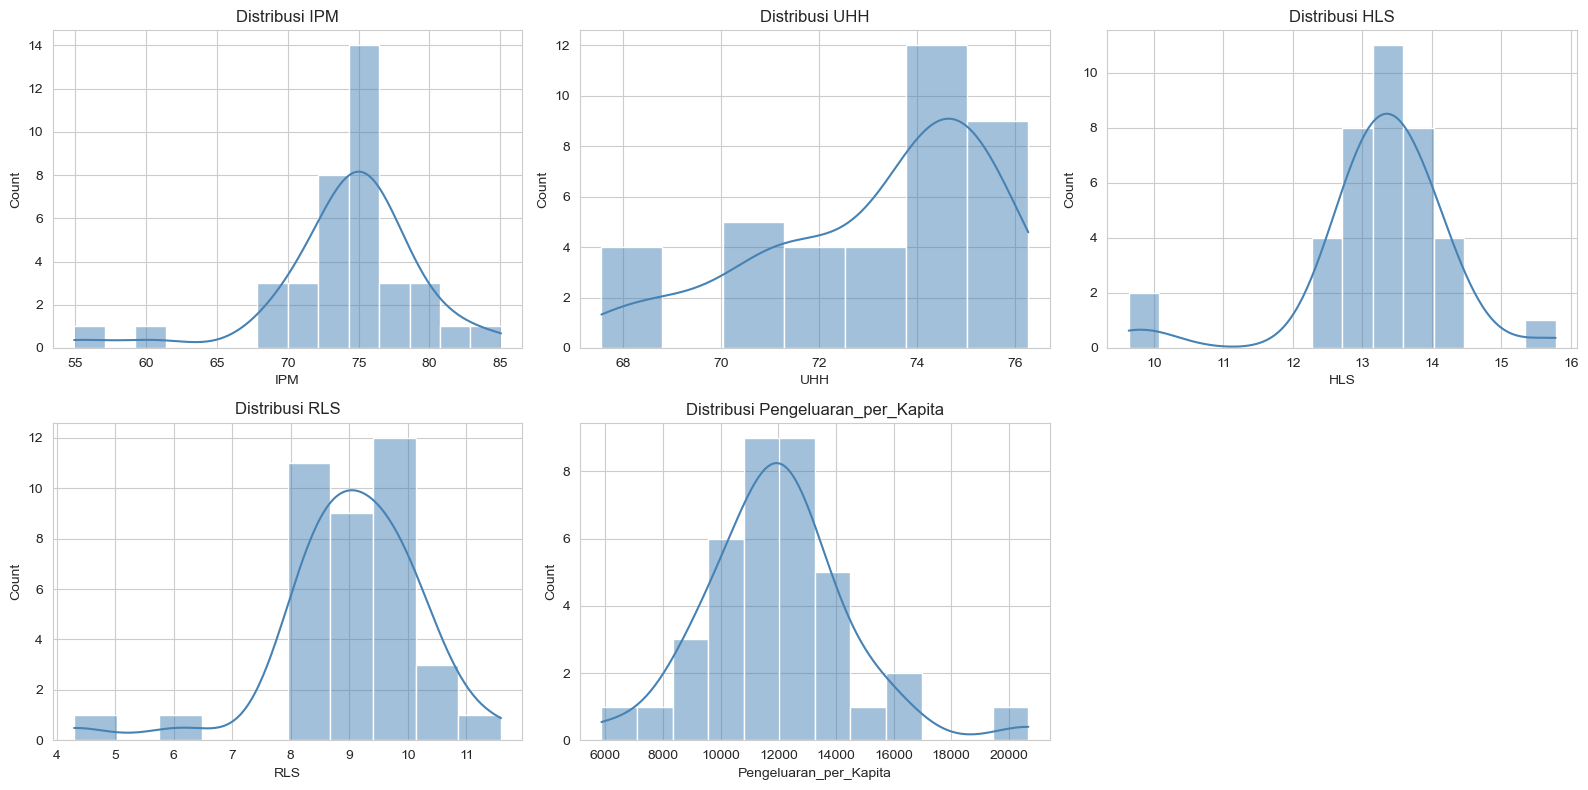

In [7]:
fitur = ["IPM", "UHH", "HLS", "RLS", "Pengeluaran_per_Kapita"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(fitur):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribusi {col}")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


### 3.3 Korelasi Antar Variabel

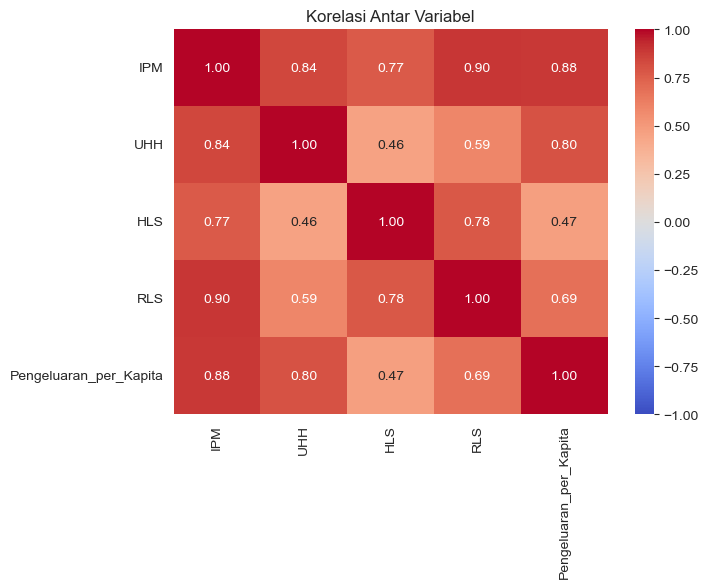

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[fitur].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Korelasi Antar Variabel")
plt.show()


### 3.4 Provinsi dengan IPM Tertinggi dan Terendah

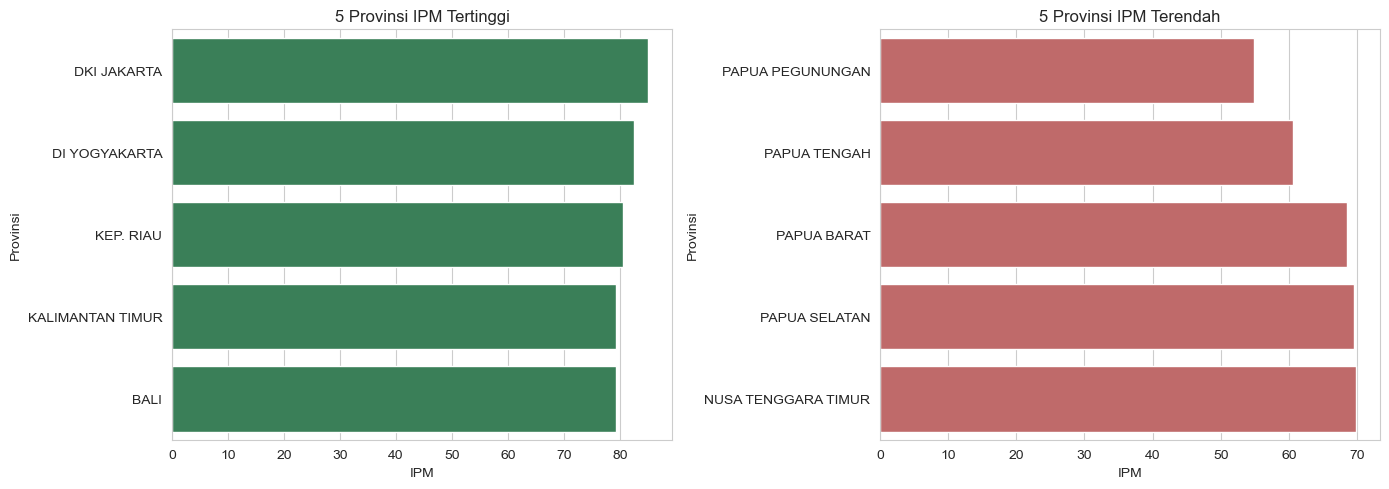

In [9]:
top5 = df.nlargest(5, "IPM")[["Provinsi", "IPM"]]
bottom5 = df.nsmallest(5, "IPM")[["Provinsi", "IPM"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top5, x="IPM", y="Provinsi", ax=axes[0], color="seagreen")
axes[0].set_title("5 Provinsi IPM Tertinggi")

sns.barplot(data=bottom5, x="IPM", y="Provinsi", ax=axes[1], color="indianred")
axes[1].set_title("5 Provinsi IPM Terendah")

plt.tight_layout()
plt.show()


## 4. Preprocessing: Standardisasi Data

K-Medoids berbasis jarak (distance-based), sehingga variabel dengan skala besar (misalnya Pengeluaran per Kapita dalam ribuan rupiah) dapat mendominasi hasil clustering jika tidak distandardisasi. Oleh karena itu, seluruh variabel di-standardisasi menggunakan **Z-score**.


In [10]:
X = df[fitur].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=fitur, index=df["Provinsi"])
X_scaled_df.head()


,IPM,UHH,HLS,RLS,Pengeluaran_per_Kapita
Provinsi,,,,,
ACEH,0.386592,0.130864,1.121479,0.752367,-0.307432
SUMATERA UTARA,0.433402,0.440574,0.234463,0.858619,-0.025693
SUMATERA BARAT,0.589435,0.658680,1.032777,0.605249,0.031293
RIAU,0.402195,0.680491,0.175328,0.425438,0.107805
JAMBI,0.172047,0.527816,0.076771,-0.064956,0.022127


## 5. Penentuan Jumlah Cluster Optimal

Digunakan dua metode untuk menentukan jumlah cluster (k) yang optimal:
1. **Elbow Method** berdasarkan inertia/cost
2. **Silhouette Score** mengukur seberapa baik pemisahan antar cluster


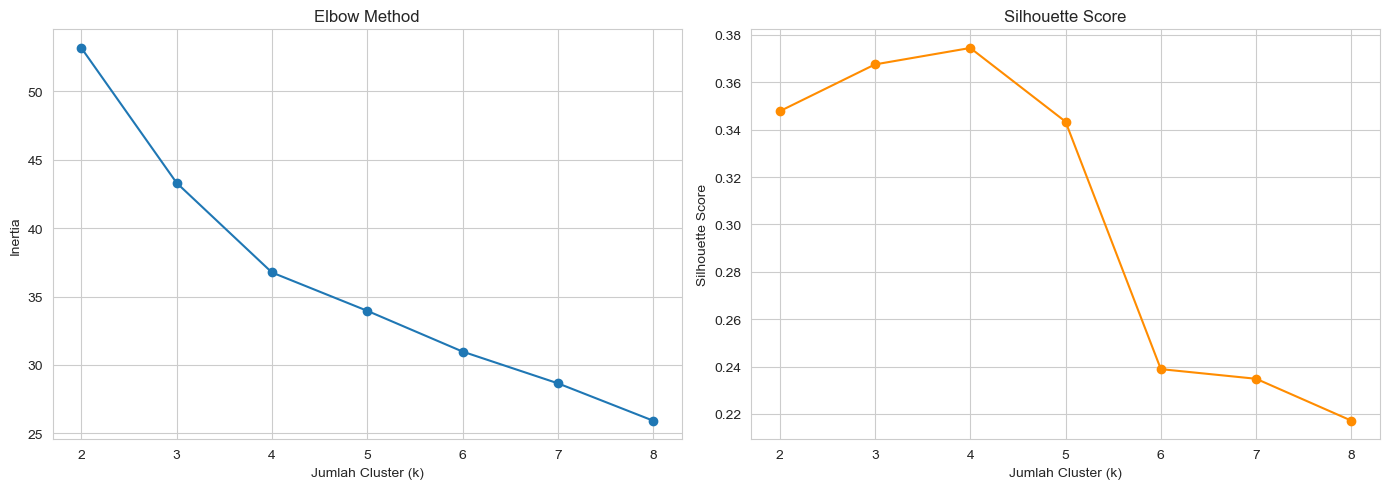

k=2: silhouette score = 0.3478
k=3: silhouette score = 0.3675
k=4: silhouette score = 0.3745
k=5: silhouette score = 0.3434
k=6: silhouette score = 0.2389
k=7: silhouette score = 0.2348
k=8: silhouette score = 0.2171


In [12]:
from sklearn.metrics import pairwise_distances

# Hitung matriks jarak (dibutuhkan oleh library kmedoids)
diss_matrix = pairwise_distances(X_scaled, metric="euclidean")

inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    result = km_lib.fasterpam(diss_matrix, k, random_state=42)
    labels = result.labels
    inertia.append(result.loss)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouette_scores):
    print(f"k={k}: silhouette score = {s:.4f}")

> **Kesimpulan :** Berdasarkan grafik di atas dan nilai silhouette score didapatkan nilai k_optimal = 4

## 6. K-Medoids Clustering

In [15]:
result_final = km_lib.fasterpam(diss_matrix, k_optimal, random_state=42)
df["Cluster"] = result_final.labels

# Tampilkan medoid (provinsi yang menjadi representasi tiap cluster)
medoid_indices = result_final.medoids
print("Provinsi yang menjadi medoid tiap cluster:")
print(df.iloc[medoid_indices][["Provinsi", "Cluster"] + fitur])

Provinsi yang menjadi medoid tiap cluster:
            Provinsi  Cluster    IPM    UHH    HLS    RLS  \
25   SULAWESI TENGAH        0  72.82  71.10  13.35   9.10   
36      PAPUA TENGAH        1  60.64  68.38   9.64   6.13   
4              JAMBI        2  75.13  74.39  13.34   8.95   
22  KALIMANTAN TIMUR        3  79.39  75.28  14.04  10.10   

    Pengeluaran_per_Kapita  
25                   10934  
36                    8036  
4                    12018  
22                   14254  


In [16]:
df[["Provinsi", "IPM", "Cluster"]].sort_values(["Cluster", "IPM"], ascending=[True, False])


,Provinsi,IPM,Cluster
34,PAPUA,74.69,0
27,SULAWESI TENGGARA,74.25,0
30,MALUKU,74.09,0
25,SULAWESI TENGAH,72.82,0
28,GORONTALO,72.62,0
31,MALUKU UTARA,72.52,0
29,SULAWESI BARAT,71.16,0
33,PAPUA BARAT DAYA,70.55,0
18,NUSA TENGGARA TIMUR,69.89,0
35,PAPUA SELATAN,69.54,0


## 7. Evaluasi Hasil Cluster

In [17]:
final_silhouette = silhouette_score(X_scaled, df["Cluster"])
print(f"Silhouette Score (k={k_optimal}): {final_silhouette:.4f}")


Silhouette Score (k=4): 0.3745


In [18]:
# Ringkasan rata-rata tiap variabel per cluster
cluster_summary = df.groupby("Cluster")[fitur].mean().round(2)
cluster_summary["Jumlah_Provinsi"] = df.groupby("Cluster").size()
cluster_summary


,IPM,UHH,HLS,RLS,Pengeluaran_per_Kapita,Jumlah_Provinsi
Cluster,,,,,,
0,71.87,70.81,13.46,9.00,10194.82,11
1,57.78,67.96,9.81,5.22,6948.50,2
2,75.32,74.38,13.23,9.03,12339.16,19
3,80.68,75.47,14.14,10.35,15681.67,6


## 8. Visualisasi Hasil Cluster

### 8.1 Visualisasi 2D dengan PCA
Karena data memiliki 5 dimensi, digunakan PCA untuk mereduksi menjadi 2 dimensi agar bisa divisualisasikan.


Variansi yang dijelaskan oleh 2 komponen PCA: 92.21%


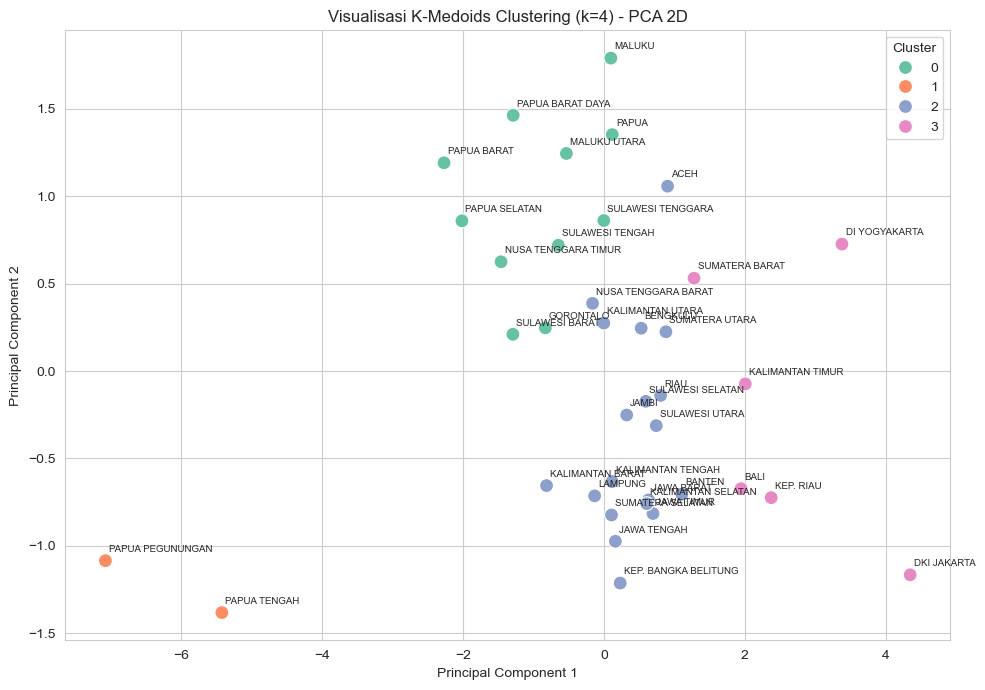

In [19]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

print(f"Variansi yang dijelaskan oleh 2 komponen PCA: {sum(pca.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=100)

for i, row in df.iterrows():
    plt.text(row["PCA1"]+0.05, row["PCA2"]+0.05, row["Provinsi"], fontsize=7)

plt.title(f"Visualisasi K-Medoids Clustering (k={k_optimal}) - PCA 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


### 8.2 Boxplot IPM per Cluster

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9448\2006525032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="IPM", palette="Set2")


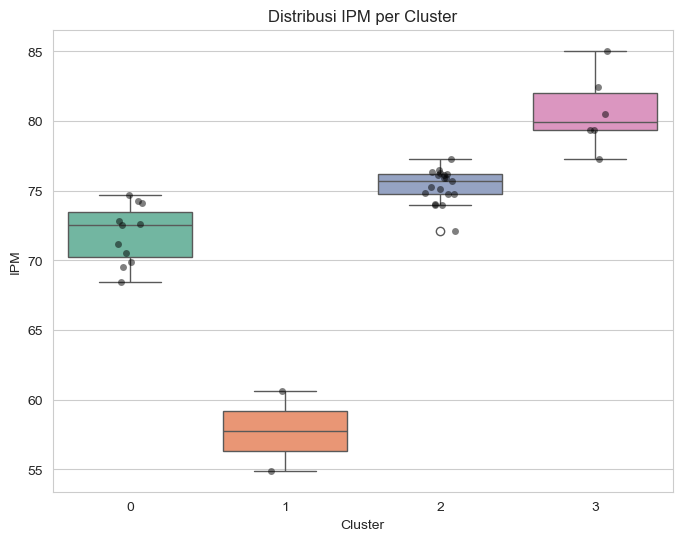

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Cluster", y="IPM", palette="Set2")
sns.stripplot(data=df, x="Cluster", y="IPM", color="black", alpha=0.5)
plt.title("Distribusi IPM per Cluster")
plt.show()


### 8.3 Silhouette Plot

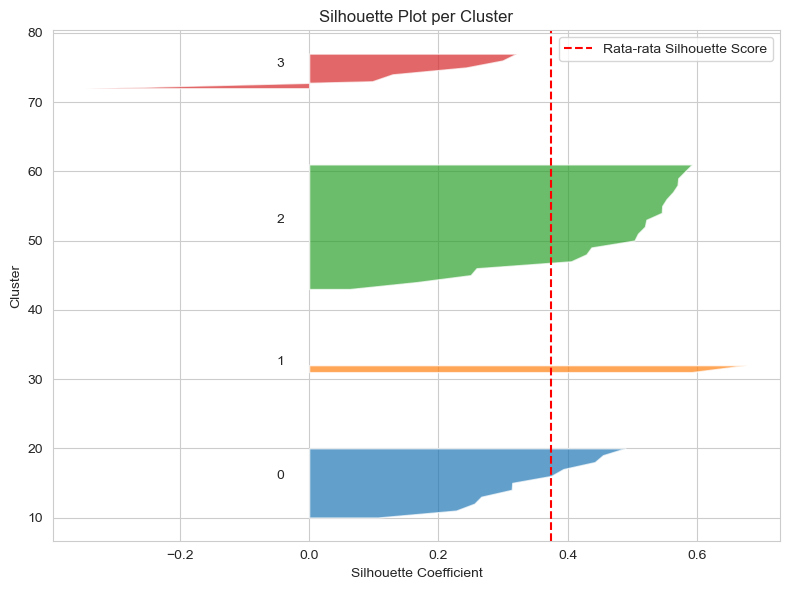

In [21]:
sil_values = silhouette_samples(X_scaled, df["Cluster"])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in sorted(df["Cluster"].unique()):
    cluster_sil = sil_values[df["Cluster"] == i]
    cluster_sil.sort()
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5*size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=final_silhouette, color="red", linestyle="--", label="Rata-rata Silhouette Score")
ax.set_title("Silhouette Plot per Cluster")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Interpretasi & Kesimpulan

Berdasarkan hasil K-Medoids clustering dengan k=4, diperoleh Silhouette Score sebesar **0.3745**, yang menunjukkan pemisahan cluster yang cukup baik.

**Karakteristik tiap cluster:**

- **Cluster 3 IPM Sangat Tinggi** (rata-rata IPM 80.68, 6 provinsi)
  Terdiri dari DKI Jakarta, DI Yogyakarta, Kepulauan Riau, Kalimantan Timur, Bali, dan Sumatera Barat. Cluster ini memiliki nilai tertinggi di seluruh indikator, termasuk pengeluaran per kapita (Rp 15,68 juta/tahun) dan rata-rata lama sekolah (10,35 tahun). Umumnya provinsi dengan pusat pemerintahan, pariwisata, atau kegiatan ekonomi tinggi.

- **Cluster 2 IPM Tinggi** (rata-rata IPM 75.32, 19 provinsi — cluster terbesar)
  Mayoritas provinsi di Indonesia, tersebar di Sumatera, Jawa, Kalimantan, dan Sulawesi seperti Jawa Barat, Jawa Timur, Riau, dan Sulawesi Selatan. Cluster ini mencerminkan kondisi pembangunan manusia "menengah-atas" yang menjadi rata-rata nasional.

- **Cluster 0 IPM Sedang** (rata-rata IPM 71.87, 11 provinsi)
  Didominasi provinsi kepulauan dan wilayah timur Indonesia seperti Papua, Maluku, Maluku Utara, Nusa Tenggara Timur, dan sebagian besar provinsi hasil pemekaran Papua (Papua Barat, Papua Barat Daya, Papua Selatan). Nilai pengeluaran per kapita dan pendidikan (HLS, RLS) berada di bawah rata-rata nasional.

- **Cluster 1 IPM Rendah** (rata-rata IPM 57.78, 2 provinsi)
  Hanya berisi **Papua Tengah** dan **Papua Pegunungan** — dua provinsi dengan capaian pembangunan manusia terendah di Indonesia. Rata-rata lama sekolah hanya 5,22 tahun dan pengeluaran per kapita di bawah Rp 7 juta/tahun, jauh di bawah cluster lainnya.

**Insight:**
- Pola cluster ini sejalan dengan disparitas pembangunan Indonesia bagian barat vs timur yang sudah lama menjadi isu kebijakan nasional.
- Cluster 1 (Papua Tengah & Papua Pegunungan) merupakan provinsi pemekaran baru yang butuh perhatian khusus dalam percepatan pembangunan SDM.
- Menariknya, Sumatera Barat masuk ke Cluster 3 (IPM sangat tinggi) meski bukan provinsi dengan pusat ekonomi utama, berbeda dari provinsi lain di cluster yang sama — ini bisa jadi temuan menarik untuk dieksplorasi lebih lanjut (misalnya terkait budaya merantau dan tingkat pendidikan yang tinggi di Sumbar).

**Kesimpulan:**
K-Medoids berhasil mengelompokkan 38 provinsi Indonesia menjadi 4 cluster yang mencerminkan tingkat pembangunan manusia berjenjang, dari IPM sangat tinggi (Cluster 3) hingga rendah (Cluster 1). Hasil ini dapat menjadi dasar rekomendasi kebijakan pemerataan pembangunan, khususnya bagi provinsi - provinsi di Cluster 0 dan 1 yang memerlukan intervensi lebih intensif dalam bidang pendidikan dan ekonomi.